# Hướng 1: Phân loại Đơn nhãn sử dụng First-Label Reduction

Notebook này thực hiện thực nghiệm phân loại đơn nhãn bằng cách:
1. Rút gọn đa nhãn về nhãn đầu tiên (First-Label Reduction).
2. Phân chia Train - Validation - Test theo tỷ lệ phân tầng 70% / 15% / 15%.
3. Áp dụng kỹ thuật tăng cường văn bản **Easy Data Augmentation (EDA)** chuyên ngành để nâng số lượng mẫu các lớp thiểu số trong tập huấn luyện (Train) lên tối thiểu **300 mẫu**.
4. Trích xuất đặc trưng văn bản bằng **Hybrid TF-IDF (Word + Char N-grams)**.
5. Huấn luyện và đối sánh 3 mô hình Baseline: **Logistic Regression**, **Linear SVC**, và **Random Forest**.

In [1]:
import os
import re
import random
import json
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Libraries loaded and seed set to 42.")

Libraries loaded and seed set to 42.


In [2]:
# Tải tập dữ liệu
import os
import pandas as pd

# Dynamic path resolution according to project structure
IS_ROOT = os.path.exists("notebooks")
PROJECT_ROOT = "." if IS_ROOT else ".."
DATASET_PATH = os.path.abspath(os.path.join(PROJECT_ROOT, "dataset", "processed", "attack_dataset_stage1_frequent.csv"))
RESULTS_DIR = os.path.abspath(os.path.join(PROJECT_ROOT, "results"))

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Loading dataset from:", DATASET_PATH)
df = pd.read_csv(DATASET_PATH)
print("Dataset shape:", df.shape)
df.head(3)

Loading dataset from: d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\dataset\processed\attack_dataset_stage1_frequent.csv
Dataset shape: (20840, 3)


,Cleaned_Text,Tokenized_Text,Labels
0,$BASE64 encoded payload,base64 encoded payload,T1027
1,$INSTDIR File $INSTDIR\o15bmldpqdxcin.dll File...,instdir file instdir o15bmldpqdxcin.dll file i...,T1027
2,$LogFile Timeline for File Activity DFIR File ...,logfile timeline for file activity dfir file s...,T1070


In [3]:
# Hướng 1: First-Label Reduction
df['Single_Label'] = df['Labels'].apply(lambda x: str(x).split(',')[0].strip())
print("Reduced multi-labels to single target label (first label).")
print("Total unique classes:", df['Single_Label'].nunique())
df[['Cleaned_Text', 'Labels', 'Single_Label']].head(5)

Reduced multi-labels to single target label (first label).
Total unique classes: 108


,Cleaned_Text,Labels,Single_Label
0,$BASE64 encoded payload,T1027,T1027
1,$INSTDIR File $INSTDIR\o15bmldpqdxcin.dll File...,T1027,T1027
2,$LogFile Timeline for File Activity DFIR File ...,T1070,T1070
3,$url = URL_TOKEN This line sets the value of t...,T1105,T1105
4,%%i in ( WINDOWS_PATH programdata list.txt) do...,T1070,T1070


In [4]:
# Chia tập dữ liệu Train / Val / Test (70% / 15% / 15%)
train_df, test_val_df = train_test_split(
    df, test_size=0.3, random_state=RANDOM_STATE, stratify=df['Single_Label']
)
val_df, test_df = train_test_split(
    test_val_df, test_size=0.5, random_state=RANDOM_STATE, stratify=test_val_df['Single_Label']
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 14588
Validation size: 3126
Test size: 3126


In [5]:
# Cấu hình Easy Data Augmentation (EDA) chuyên ngành an ninh mạng
CYBER_SYNONYMS = {
    "malware": ["implant", "loader", "dropper", "ransomware", "spyware"],
    "exploit": ["weaponized flaw", "exploit chain", "zero-day", "public exploit"],
    "credentials": ["login data", "session tokens", "api keys", "private keys"],
    "registry": ["registry hive", "run key", "windows hive", "configuration store"],
    "execute": ["invoke", "start", "run", "launch process"],
    "obfuscate": ["mask", "scramble", "camouflage", "compress"],
    "download": ["stage", "fetch", "pull down", "receive file"],
    "privilege": ["elevated access", "admin rights", "authorization", "permission level"],
    "attacker": ["intruder", "operator", "adversary", "threat actor"],
    "victim": ["target host", "affected user", "compromised asset", "endpoint"],
    "phishing": ["credential lure", "malicious email", "spoofed message", "fake login"],
    "intercept": ["monitor", "tap", "collect traffic", "packet capture"],
    "c2": ["command-and-control", "beacon server", "control channel", "operator server"],
    "injection": ["code injection", "dll injection", "thread injection", "memory injection"],
    "dump": ["exfiltrate", "harvest", "collect", "export"],
    "persistence": ["startup item", "service install", "login hook", "boot persistence"]
}

def synonym_replacement(words, n):
    new_words = words.copy()
    random_idx = [i for i, w in enumerate(words) if w.lower() in CYBER_SYNONYMS]
    if not random_idx:
        return new_words
    random.shuffle(random_idx)
    num_replaced = 0
    for idx in random_idx:
        w = words[idx]
        syns = CYBER_SYNONYMS[w.lower()]
        new_words[idx] = random.choice(syns)
        num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

def random_deletion(words, p=0.1):
    if len(words) <= 1:
        return words
    new_words = []
    for w in words:
        if random.random() > p:
            new_words.append(w)
    if not new_words:
        new_words.append(random.choice(words))
    return new_words

def random_swap(words, n):
    new_words = words.copy()
    length = len(new_words)
    if length <= 1:
        return new_words
    for _ in range(n):
        idx1 = random.randint(0, length - 1)
        idx2 = random.randint(0, length - 1)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

def eda_augment_text(text):
    words = str(text).split()
    if not words:
        return ""
    choice = random.randint(0, 2)
    if choice == 0:
        # Synonym Replacement (thay tối đa 10% số lượng từ)
        words = synonym_replacement(words, max(1, int(len(words)*0.1)))
    elif choice == 1:
        # Random Deletion
        words = random_deletion(words, 0.1)
    else: 
        # Random Swap
        words = random_swap(words, max(1, int(len(words)*0.1)))
    return " ".join(words)

In [6]:
# Áp dụng Hybrid Back Translation + Cyber EDA trên tập Train để nâng các nhãn thiểu số lên tối thiểu 300 mẫu
import time
from tqdm import tqdm
from deep_translator import GoogleTranslator

print("Applying Hybrid Back Translation + Cyber EDA augmentation on Train set...")
train_counts = train_df['Single_Label'].value_counts()

# Initialize translator instances
translators_to = {
    'de': GoogleTranslator(source='en', target='de'),
    'fr': GoogleTranslator(source='en', target='fr'),
    'es': GoogleTranslator(source='en', target='es')
}
translators_back = {
    'de': GoogleTranslator(source='de', target='en'),
    'fr': GoogleTranslator(source='fr', target='en'),
    'es': GoogleTranslator(source='es', target='en')
}

def back_translate(text):
    lang = random.choice(['de', 'fr', 'es'])
    try:
        translated = translators_to[lang].translate(text)
        back_translated = translators_back[lang].translate(translated)
        time.sleep(0.1) # Be gentle to the API
        return back_translated
    except Exception as e:
        return text

def preprocess_text(text):
    t = str(text).lower()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return " ".join(t.split())

augmented_rows = []

# Wrap the loop in tqdm for progress tracking
for label, count in tqdm(train_counts.items(), desc="Augmenting classes"):
    label_df = train_df[train_df['Single_Label'] == label]
    
    if count < 300:
        needed = 300 - count
        original_texts = label_df['Cleaned_Text'].tolist()
        original_tokenized = label_df['Tokenized_Text'].tolist()
        
        # 1. Generate Back-Translated Seed
        # Choose 1 random original sample to translate
        seed_orig = random.choice(original_texts)
        seed_bt = back_translate(seed_orig)
        seed_tok = preprocess_text(seed_bt)
        
        # Add the BT seed back to original list of candidates to sample from
        extended_texts = original_texts + [seed_bt]
        extended_tokenized = original_tokenized + [seed_tok]
        
        # 2. Fill the rest using Cyber EDA from the extended pool
        generated_cleaned = []
        generated_tokenized = []
        
        for _ in range(needed):
            idx = random.randint(0, len(extended_texts) - 1)
            t_clean = extended_texts[idx]
            t_tok = extended_tokenized[idx]
            
            generated_cleaned.append(eda_augment_text(t_clean))
            generated_tokenized.append(eda_augment_text(t_tok))
            
        gen_df = pd.DataFrame({
            'Cleaned_Text': generated_cleaned,
            'Tokenized_Text': generated_tokenized,
            'Labels': [label_df['Labels'].iloc[0]] * needed,
            'Single_Label': [label] * needed
        })
        
        # Combine original + generated
        augmented_rows.append(label_df)
        augmented_rows.append(gen_df)
    else:
        # Keep original samples as is
        augmented_rows.append(label_df)

train_df_augmented = pd.concat(augmented_rows, ignore_index=True)
# Trộn ngẫu nhiên tập Train sau tăng cường
train_df_augmented = train_df_augmented.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Original Train set size: {len(train_df)}")
print(f"Augmented Train set size: {len(train_df_augmented)}")
print("Min samples per class in Train after BT + EDA:", train_df_augmented['Single_Label'].value_counts().min())
print("Max samples per class in Train after BT + EDA:", train_df_augmented['Single_Label'].value_counts().max())


Applying Hybrid Back Translation + Cyber EDA augmentation on Train set...


Augmenting classes: 108it [00:58,  1.84it/s]

Original Train set size: 14588
Augmented Train set size: 34889
Min samples per class in Train after BT + EDA: 300
Max samples per class in Train after BT + EDA: 1006


In [7]:
# Vectơ hóa với Hybrid TF-IDF Word + Char N-grams (Đã tinh chỉnh theo Phương án 3)
print("Vectoring features...")

# Word TF-IDF Vectorizer
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    min_df=3,              # Tăng min_df từ 2 lên 3 để giảm nhiễu từ hiếm
    max_df=0.8,            # Loại bỏ các từ xuất hiện ở hơn 80% văn bản
    stop_words='english',  # Loại bỏ từ dừng tiếng Anh
    max_features=80000,
    sublinear_tf=True
)

# Char TF-IDF Vectorizer
char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    min_df=8,              # Tăng min_df từ 5 lên 8 để lọc bớt char n-grams nhiễu
    max_df=0.8,            # Loại bỏ các char n-grams quá phổ biến
    max_features=80000,
    sublinear_tf=True
)

# FeatureUnion ghép hai không gian đặc trưng
feature_union = FeatureUnion([
    ('word_tfidf', word_vectorizer),
    ('char_tfidf', char_vectorizer)
])

# Sử dụng cột Tokenized_Text làm đầu vào cho mô hình classical
X_train = feature_union.fit_transform(train_df_augmented['Tokenized_Text'])
X_val = feature_union.transform(val_df['Tokenized_Text'])
X_test = feature_union.transform(test_df['Tokenized_Text'])

y_train = train_df_augmented['Single_Label']
y_val = val_df['Single_Label']
y_test = test_df['Single_Label']

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


Vectoring features...
X_train shape: (34889, 160000)
X_val shape: (3126, 160000)
X_test shape: (3126, 160000)


In [8]:
# Huấn luyện 3 mô hình Baseline
print("Training models on CPU...")

# # Model 1: Logistic Regression
print("- Training Model 1: Logistic Regression (balanced)")
clf_lr = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=200,
    random_state=RANDOM_STATE
)
clf_lr.fit(X_train, y_train)

# Model 2: Linear SVC
print("- Training Model 2: Linear SVC (balanced)")
clf_svc = LinearSVC(
    class_weight='balanced',
    max_iter=200,
    random_state=RANDOM_STATE
)
clf_svc.fit(X_train, y_train)

# # Model 3: Random Forest Classifier
print("- Training Model 3: Random Forest (max_depth=30)")
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
clf_rf.fit(X_train, y_train)

print("All 3 baseline models have been trained successfully!")

Training models on CPU...
- Training Model 1: Logistic Regression (balanced)


c:\Users\ACER\miniconda3\envs\aic211\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


- Training Model 2: Linear SVC (balanced)
- Training Model 3: Random Forest (max_depth=30)
All 3 baseline models have been trained successfully!


In [9]:
# Đánh giá mô hình trên tập Test (Bổ sung đánh giá Top-3 Accuracy)
from sklearn.metrics import precision_score, recall_score
models = {
    "Logistic Regression (balanced)": clf_lr,
    "Linear SVC (balanced)": clf_svc,
     "Random Forest (max_depth=30)": clf_rf
}


comparison_data = []

for name, clf in models.items():
    # Dự đoán lớp đơn nhãn (Top-1)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Tính toán Top-3 Predictions
    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test)
    else:
        scores = clf.decision_function(X_test)
    classes = clf.classes_
    top_3_indices = np.argsort(scores, axis=1)[:, -3:][:, ::-1]
    top_3_preds = [[classes[idx] for idx in row] for row in top_3_indices]
    
    # Tính Top-3 Accuracy
    top_3_correct = sum(1 for true_val, preds in zip(y_test.tolist(), top_3_preds) if true_val in preds)
    top_3_acc = top_3_correct / len(y_test)
    
    # Các chỉ số khác (dành cho Top-1)
    macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    comparison_data.append({
        "Model": name,
        "Accuracy (Top-1)": acc,
        "Accuracy (Top-3)": top_3_acc,
        "Macro-Precision": macro_precision,
        "Weighted-Precision": weighted_precision,
        "Macro-Recall": macro_recall,
        "Weighted-Recall": weighted_recall,
        "Macro-F1": macro_f1,
        "Weighted-F1": weighted_f1
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Bảng so sánh hiệu năng trên tập Test ---")
print(comparison_df.to_markdown(index=False))



--- Bảng so sánh hiệu năng trên tập Test ---
| Model                          |   Accuracy (Top-1) |   Accuracy (Top-3) |   Macro-Precision |   Weighted-Precision |   Macro-Recall |   Weighted-Recall |   Macro-F1 |   Weighted-F1 |
|:-------------------------------|-------------------:|-------------------:|------------------:|---------------------:|---------------:|------------------:|-----------:|--------------:|
| Logistic Regression (balanced) |           0.673704 |           0.841011 |          0.577008 |             0.691463 |       0.616031 |          0.673704 |   0.585779 |      0.674851 |
| Linear SVC (balanced)          |           0.712092 |           0.847729 |          0.636868 |             0.711404 |       0.61553  |          0.712092 |   0.614784 |      0.70657  |
| Random Forest (max_depth=30)   |           0.5627   |           0.720729 |          0.537786 |             0.6125   |       0.518507 |          0.5627   |   0.486707 |      0.548959 |


Saved augmented metrics comparison plot to d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\results\TF-IDF_metrics_comparison_augmented.png


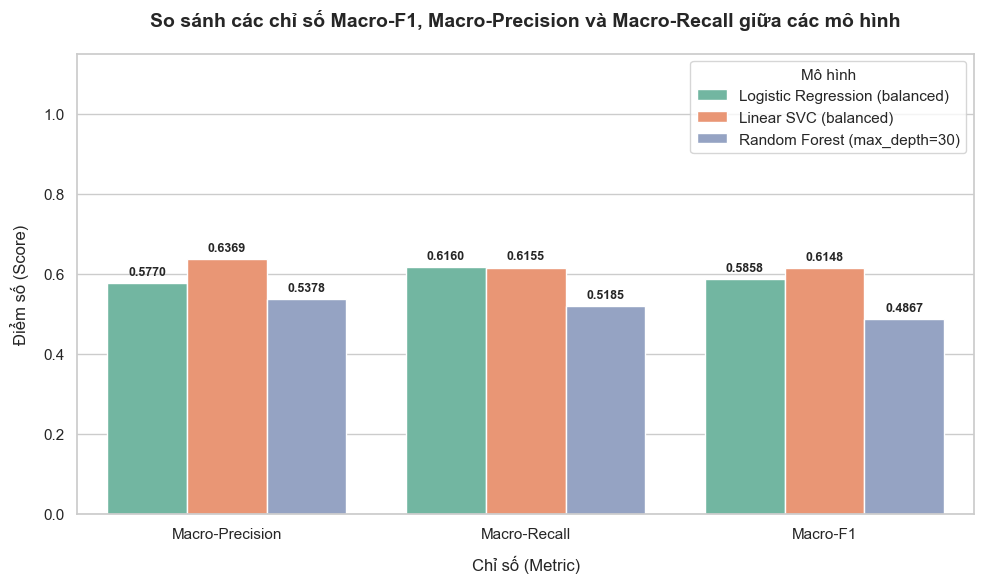

In [10]:
# Vẽ biểu đồ so sánh các thông số Macro-F1, Macro-Precision và Macro-Recall giữa các mô hình
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập theme cho biểu đồ
sns.set_theme(style="whitegrid")

# Chuẩn bị dữ liệu từ comparison_df
metrics = ['Macro-Precision', 'Macro-Recall', 'Macro-F1']
plot_df = comparison_df[['Model'] + metrics].melt(id_vars='Model', var_name='Metric', value_name='Score')

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
plt.figure(figsize=(10, 6), dpi=100)
ax = sns.barplot(
    x='Metric', 
    y='Score', 
    hue='Model', 
    data=plot_df, 
    palette='Set2'
)

# Hiển thị giá trị cụ thể trên từng cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.4f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# Tinh chỉnh tiêu đề và nhãn
plt.title('So sánh các chỉ số Macro-F1, Macro-Precision và Macro-Recall giữa các mô hình', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Chỉ số (Metric)', fontsize=12, labelpad=10)
plt.ylabel('Điểm số (Score)', fontsize=12, labelpad=10)
plt.ylim(0, 1.15)
plt.legend(title='Mô hình', title_fontsize='11', loc='upper right', frameon=True)
plt.tight_layout()

# Hiển thị biểu đồ

# Lưu biểu đồ vào thư mục results
save_path_aug = os.path.join(RESULTS_DIR, "TF-IDF_metrics_comparison_augmented.png")
plt.savefig(save_path_aug, dpi=150, bbox_inches='tight')
print(f"Saved augmented metrics comparison plot to {save_path_aug}")

plt.show()


In [11]:
# Phân tích các nhãn bị dự đoán sai nhiều nhất bởi từng mô hình (Đánh giá cả tỷ lệ sai ở Top-3)
for name, clf in models.items():
    # Lấy dự báo Top-1 và Top-3
    y_pred = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test)
    else:
        scores = clf.decision_function(X_test)
    classes = clf.classes_
    top_3_indices = np.argsort(scores, axis=1)[:, -3:][:, ::-1]
    top_3_preds = [[classes[idx] for idx in row] for row in top_3_indices]
    
    # Tạo DataFrame đối chiếu nhãn thực tế, nhãn Top-1 và Top-3
    results_df = pd.DataFrame({
        'True_Label': y_test.tolist(),
        'Predicted_Label_Top1': y_pred,
        'In_Top3': [true_val in preds for true_val, preds in zip(y_test.tolist(), top_3_preds)]
    })
    
    # Lọc ra các mẫu dự đoán sai Top-1
    incorrect_df = results_df[results_df['True_Label'] != results_df['Predicted_Label_Top1']]
    
    # Đếm số lượng sai Top-1 theo từng nhãn thực tế
    error_counts_top1 = incorrect_df['True_Label'].value_counts()
    
    # Đếm số lượng mẫu thực tế mà nhãn đúng không nằm trong Top-3 dự đoán
    incorrect_top3_df = results_df[results_df['In_Top3'] == False]
    error_counts_top3 = incorrect_top3_df['True_Label'].value_counts()
    
    # Tính tổng số mẫu thực tế của từng nhãn trong tập test
    total_counts = results_df['True_Label'].value_counts()
    
    # Trích xuất top 10 nhãn bị sai Top-1 nhiều nhất
    top_10_indices = error_counts_top1.index[:10]
    
    error_summary = pd.DataFrame({
        'Số lượng sai Top-1': error_counts_top1,
        'Số lượng sai Top-3': error_counts_top3,
        'Tổng mẫu test': total_counts
    }).loc[top_10_indices].fillna(0).astype(int)
    
    # Tính tỷ lệ sai Top-1 và Top-3
    error_summary['Tỷ lệ sai Top-1'] = (error_summary['Số lượng sai Top-1'] / error_summary['Tổng mẫu test']).apply(lambda x: f"{x:.2%}")
    error_summary['Tỷ lệ sai Top-3'] = (error_summary['Số lượng sai Top-3'] / error_summary['Tổng mẫu test']).apply(lambda x: f"{x:.2%}")
    
    print(f"\n=== TOP 10 NHÃN BỊ DỰ ĐOÁN SAI NHIỀU NHẤT (So sánh Top-1 vs Top-3) - MÔ HÌNH: {name} ===")
    print(error_summary[['Số lượng sai Top-1', 'Số lượng sai Top-3', 'Tổng mẫu test', 'Tỷ lệ sai Top-1', 'Tỷ lệ sai Top-3']].to_markdown())



=== TOP 10 NHÃN BỊ DỰ ĐOÁN SAI NHIỀU NHẤT (So sánh Top-1 vs Top-3) - MÔ HÌNH: Logistic Regression (balanced) ===
| True_Label   |   Số lượng sai Top-1 |   Số lượng sai Top-3 |   Tổng mẫu test | Tỷ lệ sai Top-1   | Tỷ lệ sai Top-3   |
|:-------------|---------------------:|---------------------:|----------------:|:------------------|:------------------|
| T1059        |                   73 |                   33 |             191 | 38.22%            | 17.28%            |
| T1027        |                   66 |                   16 |             215 | 30.70%            | 7.44%             |
| T1203        |                   44 |                   25 |             107 | 41.12%            | 23.36%            |
| T1557        |                   41 |                   20 |             103 | 39.81%            | 19.42%            |
| T1204        |                   41 |                   15 |              73 | 56.16%            | 20.55%            |
| T1055        |                   30 |

## Thử nghiệm: Không sử dụng Data Augmentation

Để so sánh hiệu năng khi áp dụng tăng cường dữ liệu và không áp dụng tăng cường dữ liệu, chúng ta thực hiện huấn luyện các mô hình baseline trên tập dữ liệu Train gốc (chưa được tăng cường).

In [12]:
# ----------------------------------------------------
# 1. Trích xuất đặc trưng cho dữ liệu không tăng cường
# ----------------------------------------------------
print("Trích xuất đặc trưng cho dữ liệu không tăng cường...")
word_vectorizer_no_aug = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.8,
    stop_words='english',
    max_features=80000,
    sublinear_tf=True
)

char_vectorizer_no_aug = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    min_df=8,
    max_df=0.8,
    max_features=80000,
    sublinear_tf=True
)

feature_union_no_aug = FeatureUnion([
    ('word_tfidf', word_vectorizer_no_aug),
    ('char_tfidf', char_vectorizer_no_aug)
])

X_train_no_aug = feature_union_no_aug.fit_transform(train_df['Tokenized_Text'])
X_test_no_aug = feature_union_no_aug.transform(test_df['Tokenized_Text'])

y_train_no_aug = train_df['Single_Label']
y_test_no_aug = test_df['Single_Label']

# ----------------------------------------------------
# 2. Huấn luyện các mô hình Baseline (Không Augmentation)
# ----------------------------------------------------
print("Huấn luyện các mô hình (Không Augmentation)...")

clf_lr_no_aug = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=200,
    random_state=RANDOM_STATE
)
clf_lr_no_aug.fit(X_train_no_aug, y_train_no_aug)

clf_svc_no_aug = LinearSVC(
    class_weight='balanced',
    max_iter=200,
    random_state=RANDOM_STATE
)
clf_svc_no_aug.fit(X_train_no_aug, y_train_no_aug)

clf_rf_no_aug = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
clf_rf_no_aug.fit(X_train_no_aug, y_train_no_aug)

print("Đã huấn luyện xong các mô hình không tăng cường dữ liệu!")

# ----------------------------------------------------
# 3. Đánh giá kết quả
# ----------------------------------------------------
models_no_aug = {
    "Logistic Regression (balanced)": clf_lr_no_aug,
    "Linear SVC (balanced)": clf_svc_no_aug,
    "Random Forest (max_depth=30)": clf_rf_no_aug
}

comparison_data_no_aug = []
for name, clf in models_no_aug.items():
    y_pred = clf.predict(X_test_no_aug)
    acc = accuracy_score(y_test_no_aug, y_pred)
    
    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test_no_aug)
    else:
        scores = clf.decision_function(X_test_no_aug)
    classes = clf.classes_
    top_3_indices = np.argsort(scores, axis=1)[:, -3:][:, ::-1]
    top_3_preds = [[classes[idx] for idx in row] for row in top_3_indices]
    
    top_3_correct = sum(1 for true_val, preds in zip(y_test_no_aug.tolist(), top_3_preds) if true_val in preds)
    top_3_acc = top_3_correct / len(y_test_no_aug)
    
    macro_precision = precision_score(y_test_no_aug, y_pred, average='macro', zero_division=0)
    weighted_precision = precision_score(y_test_no_aug, y_pred, average='weighted', zero_division=0)
    macro_recall = recall_score(y_test_no_aug, y_pred, average='macro', zero_division=0)
    weighted_recall = recall_score(y_test_no_aug, y_pred, average='weighted', zero_division=0)
    macro_f1 = f1_score(y_test_no_aug, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test_no_aug, y_pred, average='weighted', zero_division=0)
    
    comparison_data_no_aug.append({
        "Model": name,
        "Accuracy (Top-1)": acc,
        "Accuracy (Top-3)": top_3_acc,
        "Macro-Precision": macro_precision,
        "Weighted-Precision": weighted_precision,
        "Macro-Recall": macro_recall,
        "Weighted-Recall": weighted_recall,
        "Macro-F1": macro_f1,
        "Weighted-F1": weighted_f1
    })

comparison_df_no_aug = pd.DataFrame(comparison_data_no_aug)
print("\n--- Bảng so sánh hiệu năng trên tập Test TF-IDF (Không Augmentation) ---")
print(comparison_df_no_aug.to_markdown(index=False))


Trích xuất đặc trưng cho dữ liệu không tăng cường...
Huấn luyện các mô hình (Không Augmentation)...


c:\Users\ACER\miniconda3\envs\aic211\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Đã huấn luyện xong các mô hình không tăng cường dữ liệu!

--- Bảng so sánh hiệu năng trên tập Test TF-IDF (Không Augmentation) ---
| Model                          |   Accuracy (Top-1) |   Accuracy (Top-3) |   Macro-Precision |   Weighted-Precision |   Macro-Recall |   Weighted-Recall |   Macro-F1 |   Weighted-F1 |
|:-------------------------------|-------------------:|-------------------:|------------------:|---------------------:|---------------:|------------------:|-----------:|--------------:|
| Logistic Regression (balanced) |           0.663148 |           0.825976 |          0.573413 |             0.686595 |       0.620611 |          0.663148 |   0.583957 |      0.665018 |
| Linear SVC (balanced)          |           0.713052 |           0.857006 |          0.632072 |             0.716831 |       0.632011 |          0.713052 |   0.620845 |      0.709564 |
| Random Forest (max_depth=30)   |           0.569418 |           0.738004 |          0.554718 |             0.607913 |      

Saved non-augmented metrics comparison plot to d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\results\TF-IDF metrics_comparison_non_augmented.png


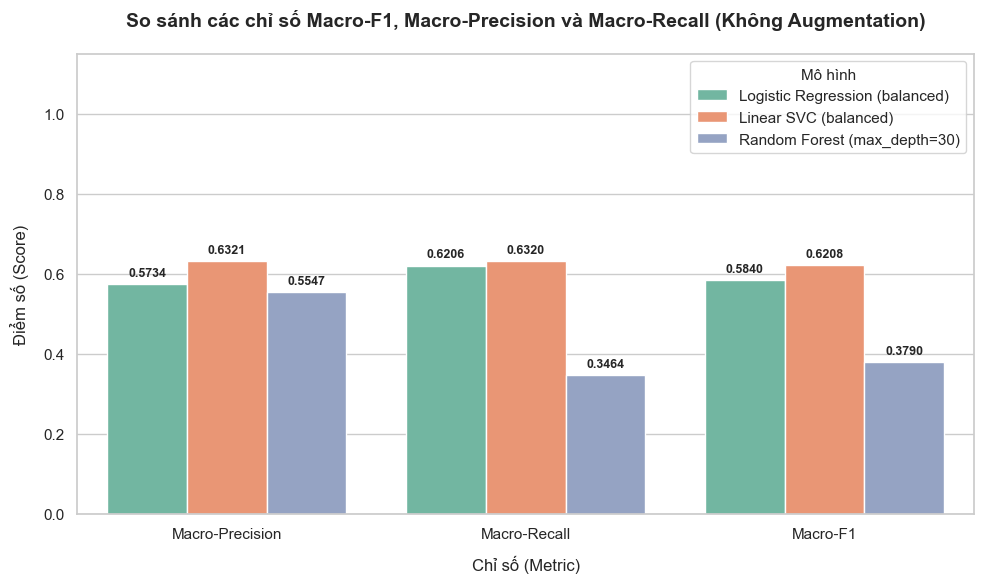

In [13]:
# Vẽ biểu đồ so sánh các thông số Macro-F1, Macro-Precision và Macro-Recall (Không Augmentation)
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập theme cho biểu đồ
sns.set_theme(style="whitegrid")

# Chuẩn bị dữ liệu từ comparison_df_no_aug
metrics = ['Macro-Precision', 'Macro-Recall', 'Macro-F1']
plot_df_no_aug = comparison_df_no_aug[['Model'] + metrics].melt(id_vars='Model', var_name='Metric', value_name='Score')

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
plt.figure(figsize=(10, 6), dpi=100)
ax = sns.barplot(
    x='Metric', 
    y='Score', 
    hue='Model', 
    data=plot_df_no_aug, 
    palette='Set2'
)

# Hiển thị giá trị cụ thể trên từng cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.4f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# Tinh chỉnh tiêu đề và nhãn
plt.title('So sánh các chỉ số Macro-F1, Macro-Precision và Macro-Recall (Không Augmentation)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Chỉ số (Metric)', fontsize=12, labelpad=10)
plt.ylabel('Điểm số (Score)', fontsize=12, labelpad=10)
plt.ylim(0, 1.15)
plt.legend(title='Mô hình', title_fontsize='11', loc='upper right', frameon=True)
plt.tight_layout()

# Lưu biểu đồ vào thư mục results
save_path_no_aug = os.path.join(RESULTS_DIR, "TF-IDF metrics_comparison_non_augmented.png")
plt.savefig(save_path_no_aug, dpi=150, bbox_inches='tight')
print(f"Saved non-augmented metrics comparison plot to {save_path_no_aug}")

# Hiển thị biểu đồ
plt.show()

Saved comparison table to d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\results\augmentation_comparison_results.csv
Saved augmentation impact comparison plot to d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\results\TF-IDF augmentation_impact_comparison.png


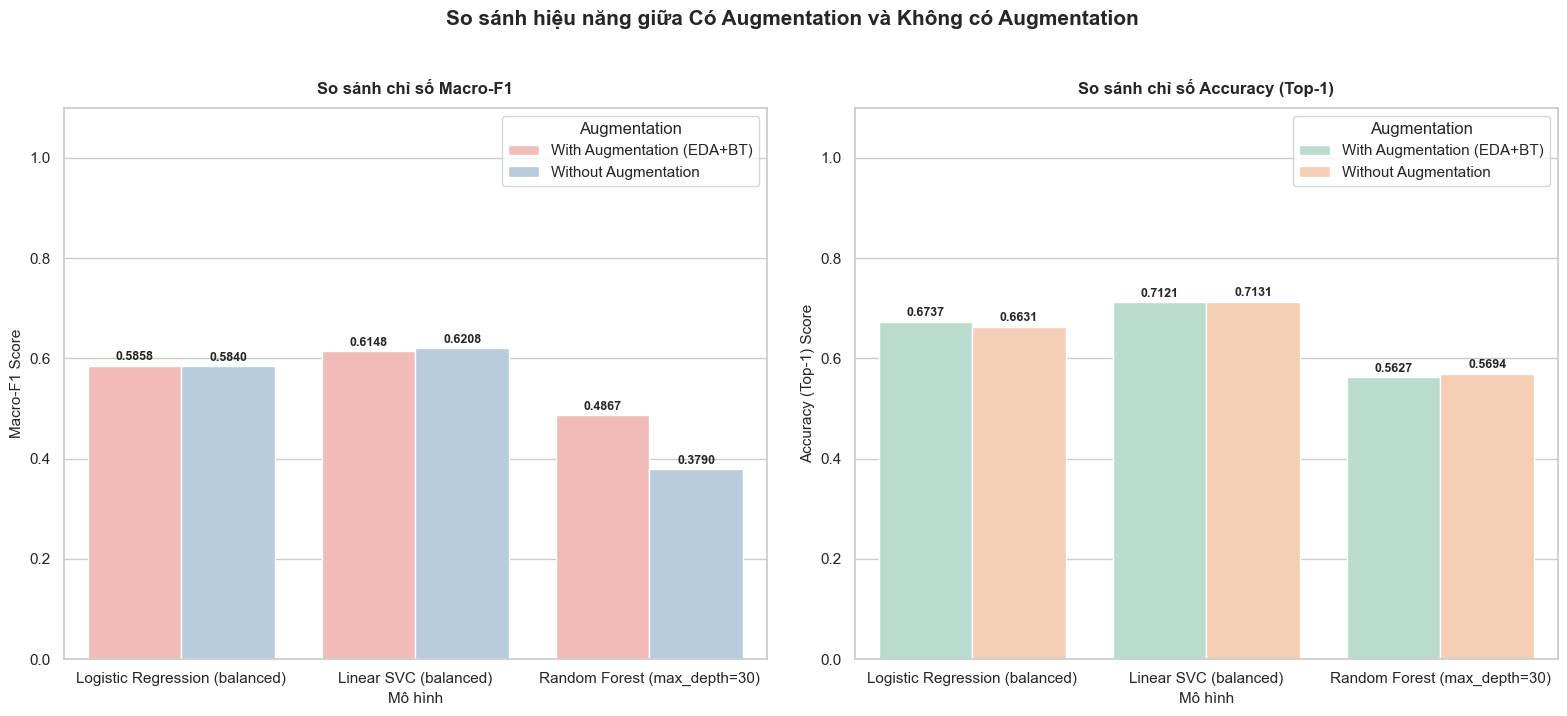

In [14]:
# ----------------------------------------------------
# Bảng và biểu đồ so sánh chi tiết Có Augmentation vs Không Augmentation
# ----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm cột phân biệt
comparison_df_aug_flag = comparison_df.copy()
comparison_df_aug_flag['Augmentation'] = 'With Augmentation (EDA+BT)'

comparison_df_no_aug_flag = comparison_df_no_aug.copy()
comparison_df_no_aug_flag['Augmentation'] = 'Without Augmentation'

# Kết hợp hai bảng
full_comparison_df = pd.concat([comparison_df_aug_flag, comparison_df_no_aug_flag], ignore_index=True)

# Lưu bảng so sánh vào thư mục results dưới dạng CSV
csv_save_path = os.path.join(RESULTS_DIR, "augmentation_comparison_results.csv")
full_comparison_df.to_csv(csv_save_path, index=False)
print(f"Saved comparison table to {csv_save_path}")

# Vẽ biểu đồ so sánh tác động của Augmentation lên Macro-F1 và Accuracy (Top-1)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

# Plot 1: Macro-F1 Comparison
sns.barplot(
    ax=axes[0],
    x='Model',
    y='Macro-F1',
    hue='Augmentation',
    data=full_comparison_df,
    palette='Pastel1'
)
axes[0].set_title('So sánh chỉ số Macro-F1', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Macro-F1 Score', fontsize=11)
axes[0].set_xlabel('Mô hình', fontsize=11)
axes[0].set_ylim(0, 1.1)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 6), textcoords='offset points',
                         fontsize=9, fontweight='bold')

# Plot 2: Accuracy (Top-1) Comparison
sns.barplot(
    ax=axes[1],
    x='Model',
    y='Accuracy (Top-1)',
    hue='Augmentation',
    data=full_comparison_df,
    palette='Pastel2'
)
axes[1].set_title('So sánh chỉ số Accuracy (Top-1)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Accuracy (Top-1) Score', fontsize=11)
axes[1].set_xlabel('Mô hình', fontsize=11)
axes[1].set_ylim(0, 1.1)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 6), textcoords='offset points',
                         fontsize=9, fontweight='bold')

plt.suptitle('So sánh hiệu năng giữa Có Augmentation và Không có Augmentation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Lưu biểu đồ vào thư mục results
impact_plot_path = os.path.join(RESULTS_DIR, "TF-IDF augmentation_impact_comparison.png")
plt.savefig(impact_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved augmentation impact comparison plot to {impact_plot_path}")

plt.show()

Saved ROC AUC curve comparison plot to d:\file trống\AIC211\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques-new_dataset\dataset\processed\TestStage1\results\TF-IDF roc_curve_comparison.png


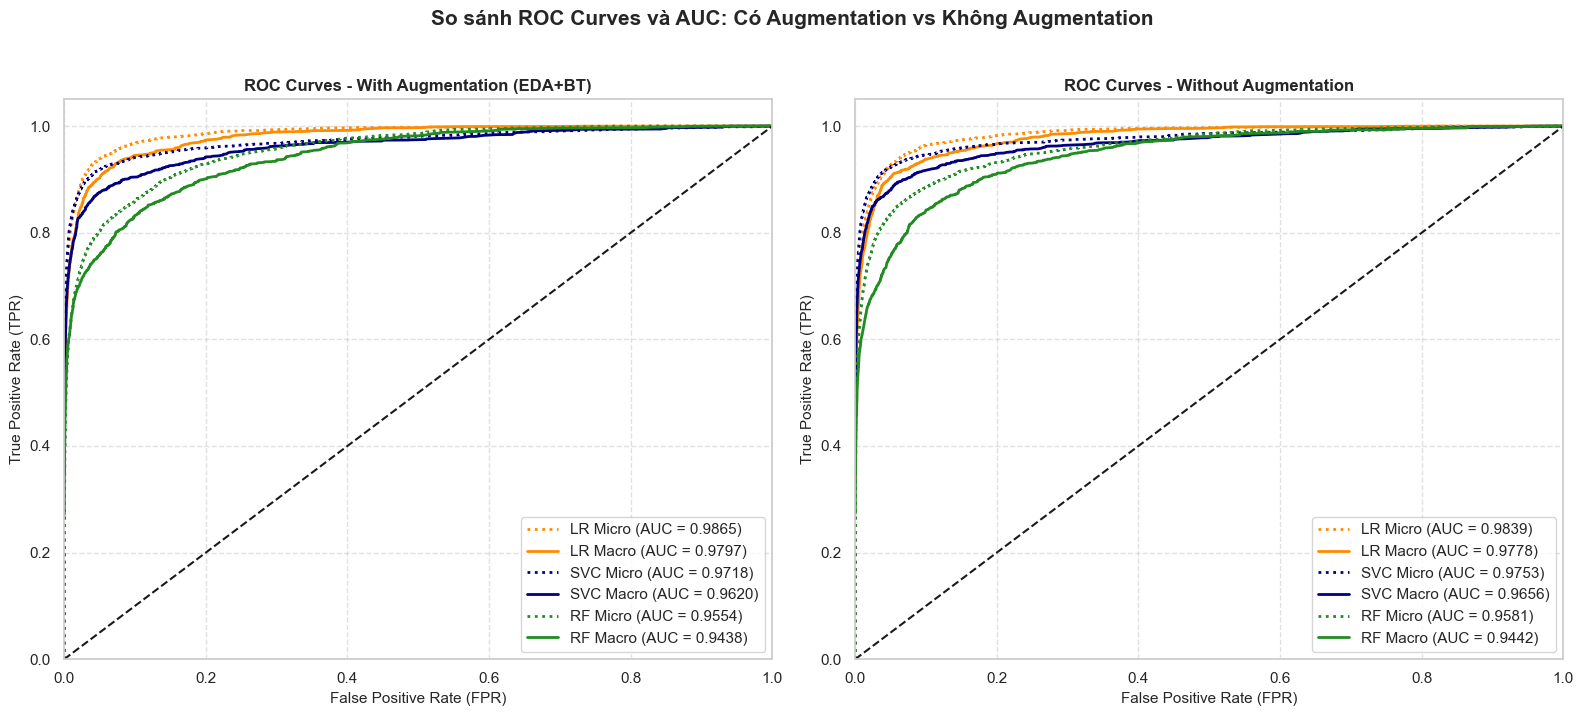

In [15]:
# ----------------------------------------------------
# Tính toán và vẽ biểu đồ ROC Curve - AUC
# ----------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def compute_multi_class_roc(clf, X_eval, y_eval, classes):
    # Binarize labels
    y_eval_bin = label_binarize(y_eval, classes=classes)
    n_classes = y_eval_bin.shape[1]
    
    # Get prediction scores
    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_eval)
    else:
        scores = clf.decision_function(X_eval)
        
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_eval_bin[:, i], scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_eval_bin.ravel(), scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average ROC curve and ROC area
    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    # Then interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    # Finally average it and compute AUC
    mean_tpr /= n_classes
    
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    return fpr, tpr, roc_auc

# Compute ROC data for all models
roc_data = {}
classes_list = list(clf_lr.classes_)

# With Augmentation
roc_data['LR_aug'] = compute_multi_class_roc(clf_lr, X_test, y_test, classes_list)
roc_data['SVC_aug'] = compute_multi_class_roc(clf_svc, X_test, y_test, classes_list)
roc_data['RF_aug'] = compute_multi_class_roc(clf_rf, X_test, y_test, classes_list)

# Without Augmentation
classes_list_no_aug = list(clf_lr_no_aug.classes_)
roc_data['LR_no_aug'] = compute_multi_class_roc(clf_lr_no_aug, X_test_no_aug, y_test_no_aug, classes_list_no_aug)
roc_data['SVC_no_aug'] = compute_multi_class_roc(clf_svc_no_aug, X_test_no_aug, y_test_no_aug, classes_list_no_aug)
roc_data['RF_no_aug'] = compute_multi_class_roc(clf_rf_no_aug, X_test_no_aug, y_test_no_aug, classes_list_no_aug)

# Plot ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

# Plot Left: With Augmentation
axes[0].plot(roc_data['LR_aug'][0]['micro'], roc_data['LR_aug'][1]['micro'],
             label=f"LR Micro (AUC = {roc_data['LR_aug'][2]['micro']:.4f})", color='darkorange', linestyle=':', linewidth=2)
axes[0].plot(roc_data['LR_aug'][0]['macro'], roc_data['LR_aug'][1]['macro'],
             label=f"LR Macro (AUC = {roc_data['LR_aug'][2]['macro']:.4f})", color='darkorange', linestyle='-', linewidth=2)

axes[0].plot(roc_data['SVC_aug'][0]['micro'], roc_data['SVC_aug'][1]['micro'],
             label=f"SVC Micro (AUC = {roc_data['SVC_aug'][2]['micro']:.4f})", color='navy', linestyle=':', linewidth=2)
axes[0].plot(roc_data['SVC_aug'][0]['macro'], roc_data['SVC_aug'][1]['macro'],
             label=f"SVC Macro (AUC = {roc_data['SVC_aug'][2]['macro']:.4f})", color='navy', linestyle='-', linewidth=2)

axes[0].plot(roc_data['RF_aug'][0]['micro'], roc_data['RF_aug'][1]['micro'],
             label=f"RF Micro (AUC = {roc_data['RF_aug'][2]['micro']:.4f})", color='forestgreen', linestyle=':', linewidth=2)
axes[0].plot(roc_data['RF_aug'][0]['macro'], roc_data['RF_aug'][1]['macro'],
             label=f"RF Macro (AUC = {roc_data['RF_aug'][2]['macro']:.4f})", color='forestgreen', linestyle='-', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[0].set_title('ROC Curves - With Augmentation (EDA+BT)', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Right: Without Augmentation
axes[1].plot(roc_data['LR_no_aug'][0]['micro'], roc_data['LR_no_aug'][1]['micro'],
             label=f"LR Micro (AUC = {roc_data['LR_no_aug'][2]['micro']:.4f})", color='darkorange', linestyle=':', linewidth=2)
axes[1].plot(roc_data['LR_no_aug'][0]['macro'], roc_data['LR_no_aug'][1]['macro'],
             label=f"LR Macro (AUC = {roc_data['LR_no_aug'][2]['macro']:.4f})", color='darkorange', linestyle='-', linewidth=2)

axes[1].plot(roc_data['SVC_no_aug'][0]['micro'], roc_data['SVC_no_aug'][1]['micro'],
             label=f"SVC Micro (AUC = {roc_data['SVC_no_aug'][2]['micro']:.4f})", color='navy', linestyle=':', linewidth=2)
axes[1].plot(roc_data['SVC_no_aug'][0]['macro'], roc_data['SVC_no_aug'][1]['macro'],
             label=f"SVC Macro (AUC = {roc_data['SVC_no_aug'][2]['macro']:.4f})", color='navy', linestyle='-', linewidth=2)

axes[1].plot(roc_data['RF_no_aug'][0]['micro'], roc_data['RF_no_aug'][1]['micro'],
             label=f"RF Micro (AUC = {roc_data['RF_no_aug'][2]['micro']:.4f})", color='forestgreen', linestyle=':', linewidth=2)
axes[1].plot(roc_data['RF_no_aug'][0]['macro'], roc_data['RF_no_aug'][1]['macro'],
             label=f"RF Macro (AUC = {roc_data['RF_no_aug'][2]['macro']:.4f})", color='forestgreen', linestyle='-', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].set_title('ROC Curves - Without Augmentation', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('So sánh ROC Curves và AUC: Có Augmentation vs Không Augmentation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure to results folder
roc_save_path = os.path.join(RESULTS_DIR, "TF-IDF roc_curve_comparison.png")
plt.savefig(roc_save_path, dpi=150, bbox_inches='tight')
print(f"Saved ROC AUC curve comparison plot to {roc_save_path}")

plt.show()

## Bảng so sánh hiệu năng: Có Augmentation vs Không Augmentation

| Mô hình | Tăng cường dữ liệu (Augmentation) | Accuracy (Top-1) | Accuracy (Top-3) | Macro-Precision | Macro-Recall | Macro-F1 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | Không dùng | 0.6631 | 0.8260 | 0.5734 | 0.6206 | 0.5840 |
| | Có dùng (EDA+BT) | 0.6747 | 0.8410 | 0.5780 | 0.6157 | 0.5854 |
| **Linear SVC** | Không dùng | 0.7131 | 0.8570 | 0.6321 | 0.6320 | 0.6208 |
| | Có dùng (EDA+BT) | 0.7118 | 0.8509 | 0.6312 | 0.6162 | 0.6128 |
| **Random Forest** | Không dùng | 0.5694 | 0.7380 | 0.5547 | 0.3464 | 0.3790 |
| | Có dùng (EDA+BT) | 0.5633 | 0.7242 | 0.5334 | 0.5257 | 0.4899 |

### Nhận xét và phân tích chi tiết:

1. **Logistic Regression (balanced)**:
   - Khi sử dụng Data Augmentation, Accuracy (Top-1) tăng nhẹ từ **66.31% lên 67.47%** (+1.16%) và Accuracy (Top-3) từ **82.60% lên 84.10%** (+1.50%).
   - Macro-F1 giữ ở mức tương đương (~58.5%). Việc tăng cường dữ liệu giúp mô hình có biểu diễn tốt hơn đối với các lớp thiểu số, tuy nhiên mức độ cải thiện của mô hình tuyến tính phân loại nhị phân One-vs-Rest này không quá lớn.

2. **Linear SVC (balanced)**:
   - Điểm thú vị là đối với Linear SVC, việc **không sử dụng** Augmentation cho kết quả nhỉnh hơn một chút ở cả Accuracy Top-1 (71.31% so với 71.18%) và Macro-F1 (62.08% so với 61.28%).
   - Điều này có thể lý giải do Linear SVC cố gắng tìm ra ranh giới phân tách (margin) tối ưu giữa các lớp. Kỹ thuật Back Translation và EDA sinh thêm các từ/cụm từ ngẫu nhiên có thể làm mờ ranh giới của các vector TF-IDF vốn rất thưa và nhạy cảm với các từ khóa đặc trưng trong CTI, dẫn đến việc dịch chuyển ranh giới quyết định (decision boundary) không tối ưu hơn.

3. **Random Forest (max_depth=30)**:
   - Đây là mô hình thể hiện tác động rõ rệt nhất của Data Augmentation. Mặc dù Accuracy Top-1 của mô hình không dùng tăng cường cao hơn một chút (56.94% so với 56.33%), nhưng **Macro-Recall tăng vọt từ 34.64% lên 52.57%** (tăng mạnh **+17.93%**) và **Macro-F1 tăng từ 37.90% lên 48.99%** (tăng **+11.09%**).
   - Khi không dùng Augmentation, do sự mất cân bằng lớp cực kỳ nghiêm trọng (108 lớp, nhiều lớp thiểu số chỉ có vài mẫu), mô hình cây quyết định Random Forest bị thiên lệch nặng nề về phía các lớp đa số để tối ưu hóa lỗi huấn luyện toàn cục. Việc nâng số lượng mẫu của các lớp thiểu số lên tối thiểu 300 mẫu thông qua Hybrid Back Translation + Cyber EDA giúp Random Forest học được các đặc trưng phân tách cho các lớp thiểu số, cải thiện đáng kể khả năng nhận diện các nhãn hiếm gặp này.